In [7]:
from lyse import *
from pylab import *
import csv
import runmanager
from runmanager.remote import *
import numpy as np
import math
from scipy.optimize import curve_fit, least_squares
import numpy as np
import matplotlib.pyplot as plt
import datetime, time
import seaborn as sns
import pandas as pd
ts=time.time()
dt=datetime.datetime.now().date()

import numpy as np
from math import sqrt

def data_mean(param1, param2, values):
    """
    Computes the mean, standard deviation, and standard error for each combination of param1 and param2 values.

    Args:
        param1: List or array of first parameter values.
        param2: List or array of second parameter values.
        values: List or array of values corresponding to the param1, param2 pairs.

    Returns:
        A dictionary containing:
        - mean_values: Dictionary with (param1, param2) pairs as keys and their mean values as values.
        - std_values: Dictionary with (param1, param2) pairs as keys and their standard deviations as values.
        - error_values: Dictionary with (param1, param2) pairs as keys and their standard errors as values.
    """
    mean_values = {}
    std_values = {}
    error_values = {}
    
    # Create unique pairs of (param1, param2)
    unique_pairs = set(zip(param1, param2))
    
    for pair in unique_pairs:
        indices = [idx for idx, val in enumerate(zip(param1, param2)) if val == pair]
        aa = [values[idx] for idx in indices]
        
        mean_values[pair] = np.mean(aa)
        std_values[pair] = np.std(aa)
        error_values[pair] = np.std(aa) / sqrt(len(aa))
        
        # Adjusting the error calculation if there are 10 or more values
        if len(aa) >= 10:
            error_values[pair] = np.std(aa) / sqrt(len(aa))
    
    return mean_values, std_values, error_values

def plot_heatmap(mean_values):
    """
    Plots a heatmap from the mean values of (param1, param2) pairs.

    Args:
        mean_values: Dictionary with (param1, param2) pairs as keys and their mean values as values.
    """
    # Step 1: Convert the mean_values dictionary to a DataFrame
    df = pd.DataFrame(list(mean_values.items()), columns=['Params', 'Mean Value'])
    
    # Split the Params tuple into two separate columns: 'param1' and 'param2'
    df['param1'] = df['Params'].apply(lambda x: x[0])
    df['param2'] = df['Params'].apply(lambda x: x[1])
    
    # Step 2: Pivot the DataFrame to create a matrix format
    df_pivot = df.pivot(index='param1', columns='param2', values='Mean Value')

    # Step 3: Plot the heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(df_pivot, annot=True, cmap="YlGnBu", linewidths=.5)
    
    # Add labels and a title
    plt.title("Heatmap of Mean Values across param1 and param2")
    plt.xlabel("param2")
    plt.ylabel("param1")
    
    plt.show()

Mean Values: {(2, 20): 9.0, (3, 30): 12.0, (1, 10): 6.0}
Standard Deviations: {(2, 20): 0.816496580927726, (3, 30): 0.816496580927726, (1, 10): 0.816496580927726}
Error Values: {(2, 20): 0.47140452079103173, (3, 30): 0.47140452079103173, (1, 10): 0.47140452079103173}


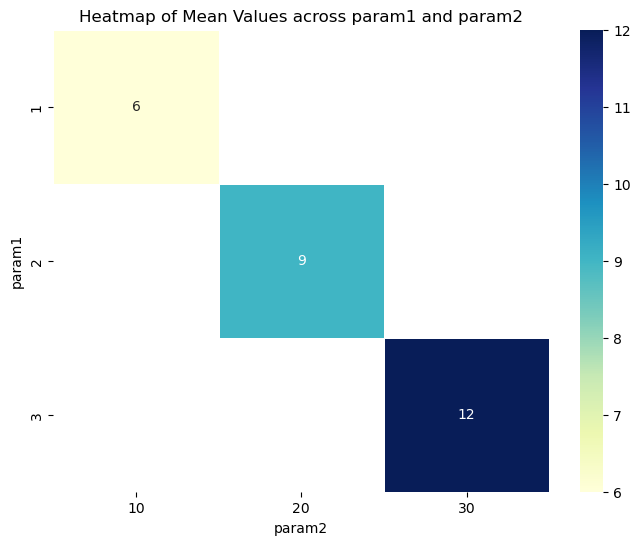

In [8]:
# Example input data
param1 = [1, 1, 1, 2, 2, 2, 3, 3, 3]
param2 = [10, 10, 10, 20, 20, 20, 30, 30, 30]
values = [5, 6, 7, 8, 9, 10, 11, 12, 13]

# Get the mean, std, and error values
mean_values, std_values, error_values = data_mean(param1, param2, values)

# Print the output
print("Mean Values:", mean_values)
print("Standard Deviations:", std_values)
print("Error Values:", error_values)

plot_heatmap(mean_values)